# 02 — SHAP Analysis

Explain model predictions using SHAP values.

**Covers**: global importance (beeswarm + bar), local waterfall explanations, interaction dependence plots.

## 1. Setup

In [1]:
import sys
sys.path.insert(0, '..')
import warnings; warnings.filterwarnings('ignore')
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.extract import load_whas500
from src.data.transform import prepare_whas500_for_ml
from src.models.train import load_model
from src.models.shap_explainer import (
    build_explainer, compute_shap_values,
    global_feature_importance, local_explanation, interaction_analysis
)
from src.visualisation.plots import (
    plot_shap_summary, plot_shap_waterfall, plot_shap_dependence
)
from src.utils.config import WHAS500Config
print('Setup OK')

Setup OK


## 2. Load Model and Data

In [2]:
whas_raw = load_whas500()
X_train, X_test, y_train, y_test, scaler = prepare_whas500_for_ml(whas_raw)

# Use XGBoost — best performing model
model = load_model('xgboost', 'whas500')
print(f'Model loaded. Test set: {len(X_test)} patients, {y_test.mean():.1%} mortality')

2026-07-18 12:01:30 | INFO     | src.data.extract                    | WHAS500 loaded (bundled via scikit-survival): 500 patients, 16 columns, 43.0% died during follow-up


2026-07-18 12:01:30 | INFO     | src.data.transform                  | WHAS500 cleaned: 500 patients, 43.0% mortality


2026-07-18 12:01:30 | INFO     | src.data.features                   | WHAS500 encoded: 14 features


2026-07-18 12:01:30 | INFO     | src.data.transform                  | Train/test split: 400 train, 100 test (stratified, seed=42)


2026-07-18 12:01:30 | INFO     | src.data.transform                  | Class balance — train: 43.0% positive, test: 43.0% positive


2026-07-18 12:01:30 | INFO     | src.data.transform                  | Features scaled: 5 numeric columns standardised


Model loaded. Test set: 100 patients, 43.0% mortality

## 3. Build SHAP Explainer and Compute Values

In [3]:
explainer   = build_explainer(model, X_train, 'xgboost')
shap_values = compute_shap_values(explainer, X_test, 'xgboost')
print(f'SHAP values shape: {shap_values.shape}')

2026-07-18 12:01:31 | INFO     | src.models.shap_explainer           | Using TreeExplainer for xgboost


2026-07-18 12:01:31 | INFO     | src.models.shap_explainer           | Computing SHAP values for xgboost (100 samples, 14 features)...


2026-07-18 12:01:31 | INFO     | src.models.shap_explainer           | SHAP values computed: shape=(100, 14), mean_abs=0.2980


SHAP values shape: (100, 14)


## 4. Global Feature Importance

In [4]:
importance = global_feature_importance(shap_values, list(X_test.columns))
print('Top 10 features by mean |SHAP|:')
for feat in importance:
    bar = '█' * int(feat['mean_abs_shap'] * 300)
    print(f"  {feat['rank']:2d}. {feat['feature']:<20} {feat['mean_abs_shap']:.4f}  {bar}")

Top 10 features by mean |SHAP|:
   1. age                  1.2519  ███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
   2. chf                  0.5540  ██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
   3. hr                   0.5342  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
   4. bmi                  0.4299  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

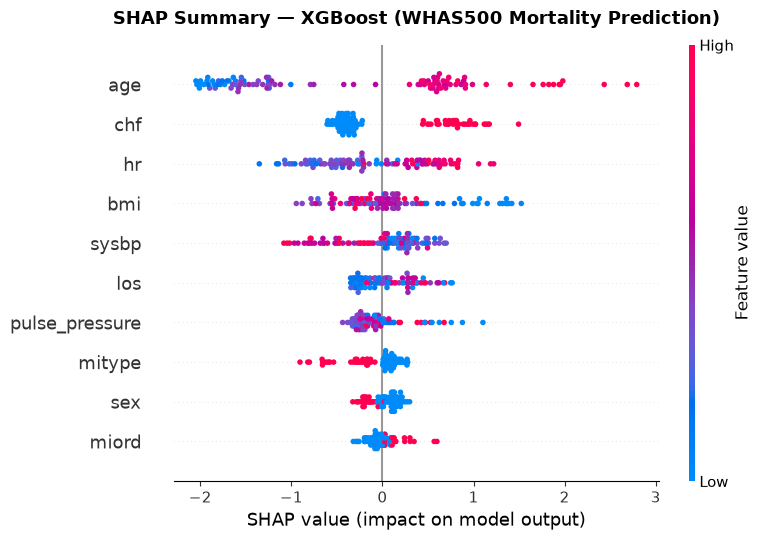

In [5]:
# SHAP beeswarm plot — the standard global importance visualisation
plot_shap_summary(shap_values, X_test, list(X_test.columns),
                  title='SHAP Summary — XGBoost (WHAS500 Mortality Prediction)',
                  plot_type='dot')
plt.show()

## 5. Local Patient Explanation

In [6]:
# Find the highest-risk patient in the test set
high_risk_idx = int(model.predict_proba(X_test)[:, 1].argmax())
expl = local_explanation(explainer, X_test, list(X_test.columns), patient_idx=high_risk_idx)

print(f'Patient {high_risk_idx}: predicted mortality risk = {expl["prediction"]:.1%}')
print(f'Baseline (mean prediction): {expl["base_value"]:.1%}')
print()
print('Top risk factors:')
for c in expl['top_risk_factors']:
    print(f"  {c['feature']:<20} value={c['value']:.2f}  SHAP=+{c['shap_value']:.4f}")
print()
print('Protective factors:')
for c in expl['top_protective']:
    print(f"  {c['feature']:<20} value={c['value']:.2f}  SHAP={c['shap_value']:.4f}")

2026-07-18 12:01:32 | INFO     | src.models.shap_explainer           | Computing SHAP values for  (1 samples, 14 features)...


2026-07-18 12:01:32 | INFO     | src.models.shap_explainer           | SHAP values computed: shape=(1, 14), mean_abs=0.3697


Patient 18: predicted mortality risk = 462.8%
Baseline (mean prediction): 9.5%

Top risk factors:
  age                  value=1.39  SHAP=+1.8785
  bmi                  value=-1.44  SHAP=+1.2888
  chf                  value=1.00  SHAP=+0.6046

Protective factors:
  sex                  value=1.00  SHAP=-0.1744
  miord                value=0.00  SHAP=-0.0607
  cvd                  value=0.00  SHAP=-0.0495


## 6. Interaction: Age × Heart Rate

<Figure size 900x600 with 0 Axes>

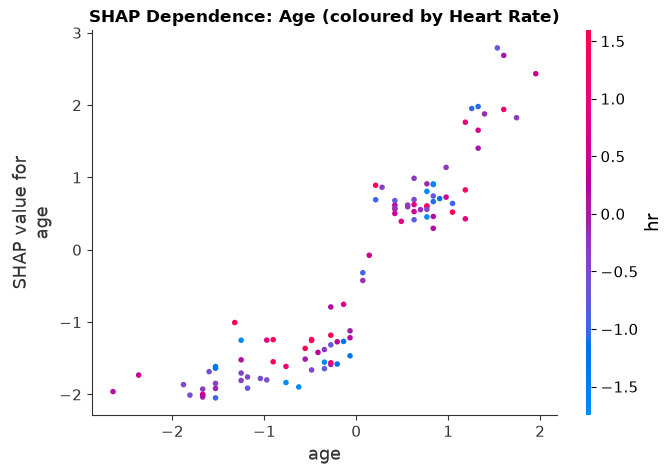

Interpretation: how does the effect of age on mortality risk
vary with the patient's initial heart rate?


In [7]:
plot_shap_dependence(
    shap_values, X_test,
    feature='age',
    interaction_feature='hr',
    title='SHAP Dependence: Age (coloured by Heart Rate)'
)
plt.show()
print('Interpretation: how does the effect of age on mortality risk\nvary with the patient\'s initial heart rate?')